<a href="https://colab.research.google.com/github/vinothkumard2006-ai/Hazardous-Waste-Detection-System-for-Scrap-Yard-Environments/blob/main/hazardous_waste_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')


Mounted at /content/drive


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset',
 'data_for_preprocessing.csv',
 'hazardous waste detection from scrap yard']

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
print(os.listdir('/content/drive/MyDrive/hazardous waste detection from scrap yard'))

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'train', 'test', 'valid']


In [4]:
print(os.listdir('/content/drive/MyDrive/hazardous waste detection from scrap yard/train'))

['labels', 'images', 'labels.cache']


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00


Train

In [6]:
from ultralytics import YOLO
# load model
model = YOLO("yolov8l.pt")

#train
model.train(
    data="/content/drive/MyDrive/hazardous waste detection from scrap yard/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/hazardous waste detection from scrap yard/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79dce2894fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

Validate

In [7]:
metrics=model.val(data="/content/drive/MyDrive/hazardous waste detection from scrap yard/data.yaml",
                  )
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

#f1 score
precision = metrics.box.mp
recall = metrics.box.mr
f1 = 2 * (precision * recall)/(precision + recall + 1e-6)
print("F1 Score:", f1)

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,608,150 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 26.3±15.9 MB/s, size: 49.7 KB)
val: Scanning /content/drive/MyDrive/hazardous waste detection from scrap yard/valid/labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.4s
                   all         21         41      0.778      0.758      0.807       0.61
             Cylinders         19         36      0.556      0.722      0.653      0.505
        Shock Absorber          3          5          1      0.794      0.962      0.715
Speed: 15.1ms preprocess, 53.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.8071221757741232
mAP50-95: 0.6101368837316167
Pre

Test

In [8]:
test=model.predict(
    source="/content/drive/MyDrive/hazardous waste detection from scrap yard/test/images",
    save=True,
    conf=0.4
)




image 1/15 /content/drive/MyDrive/hazardous waste detection from scrap yard/test/images/Screenshot-2025-02-17-000043_png_png.rf.5e31c0682a7bbaa8e49f06dff1fd3b70.jpg: 640x640 2 Cylinderss, 1 Shock Absorber, 62.5ms
image 2/15 /content/drive/MyDrive/hazardous waste detection from scrap yard/test/images/Screenshot-2025-02-17-041621_png_png.rf.95f75596b15df925ded81829295d0570.jpg: 640x640 4 Cylinderss, 62.5ms
image 3/15 /content/drive/MyDrive/hazardous waste detection from scrap yard/test/images/Screenshot-2025-02-17-041758_png_png.rf.91c13ac20a54886efe6ac1f1b729a00a.jpg: 640x640 1 Cylinders, 62.5ms
image 4/15 /content/drive/MyDrive/hazardous waste detection from scrap yard/test/images/Screenshot-2025-02-17-042157_png_png.rf.1c4bee9b59fc53ba28edcca95e5712db.jpg: 640x640 2 Cylinderss, 62.5ms
image 5/15 /content/drive/MyDrive/hazardous waste detection from scrap yard/test/images/Screenshot-2025-02-17-042548_png_png.rf.ae1bf43488fb1c9329730fac071c2877.jpg: 640x640 2 Cylinderss, 62.6ms
image 6

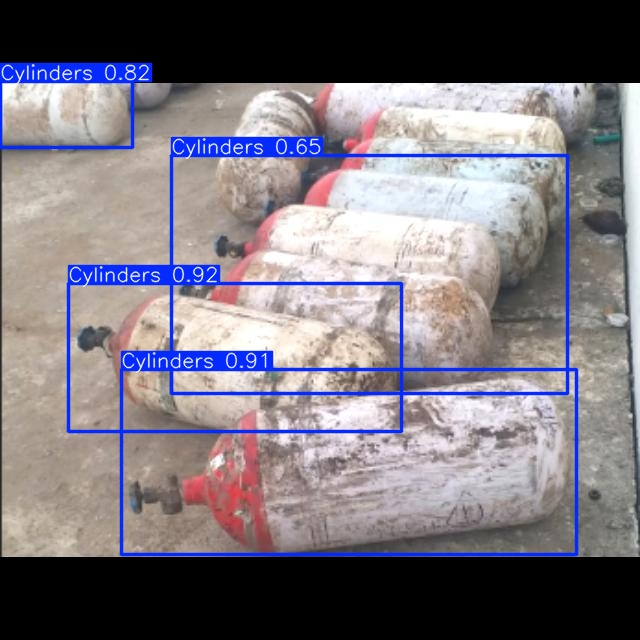

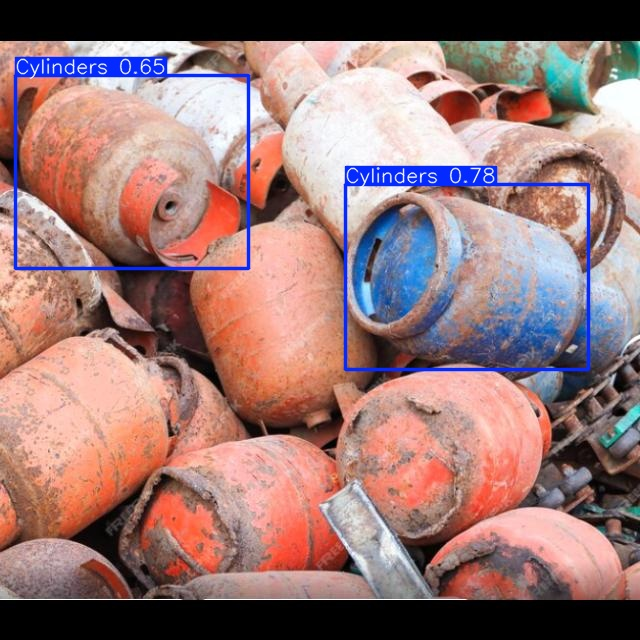

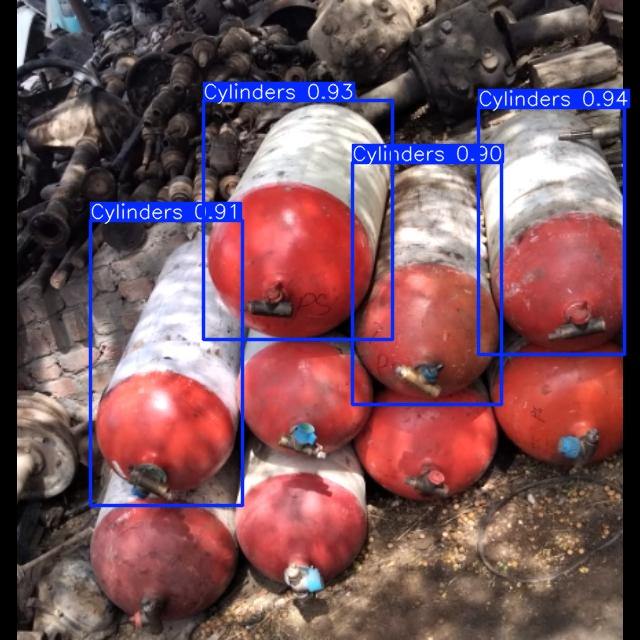

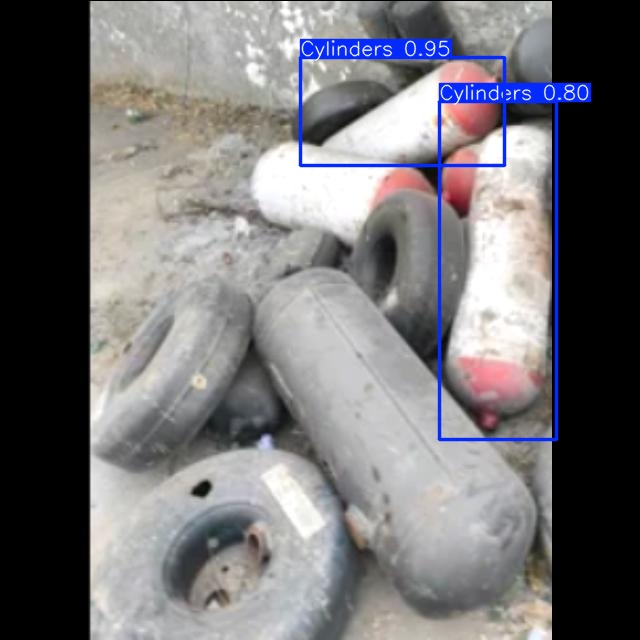

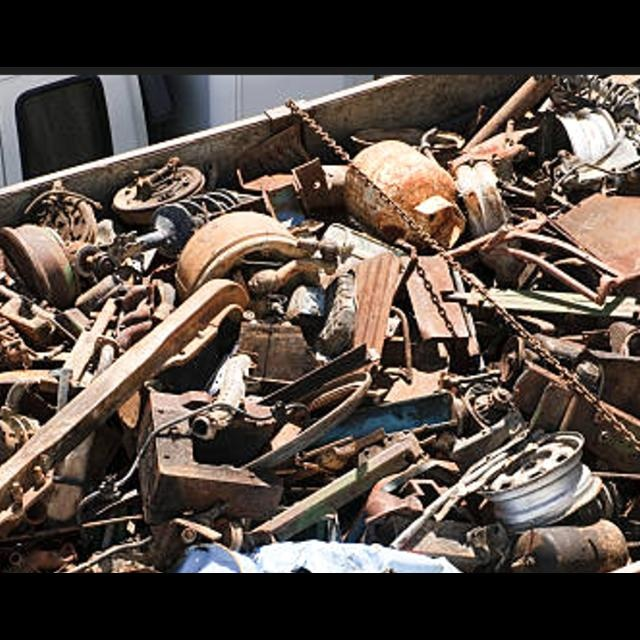

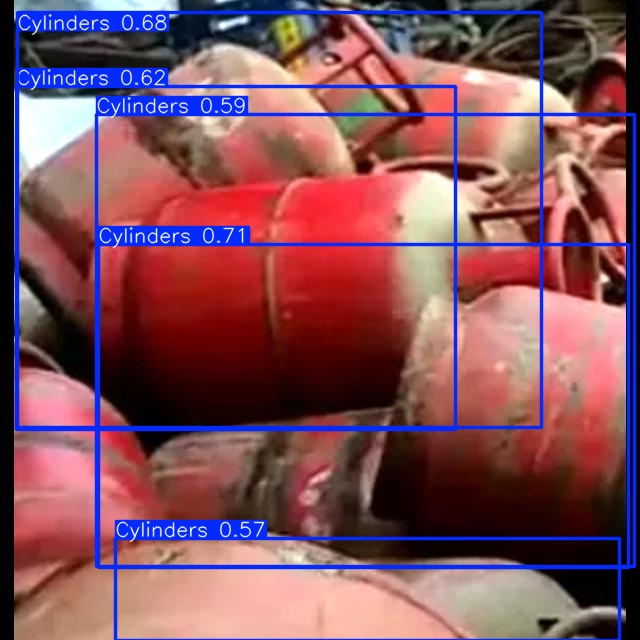

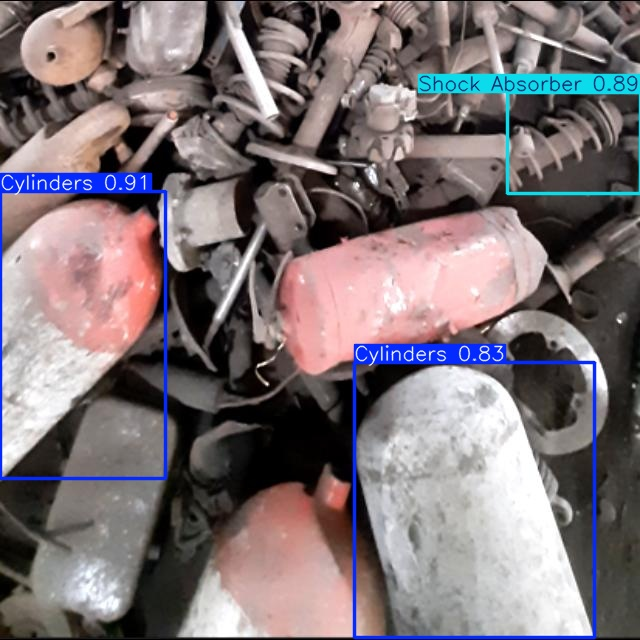

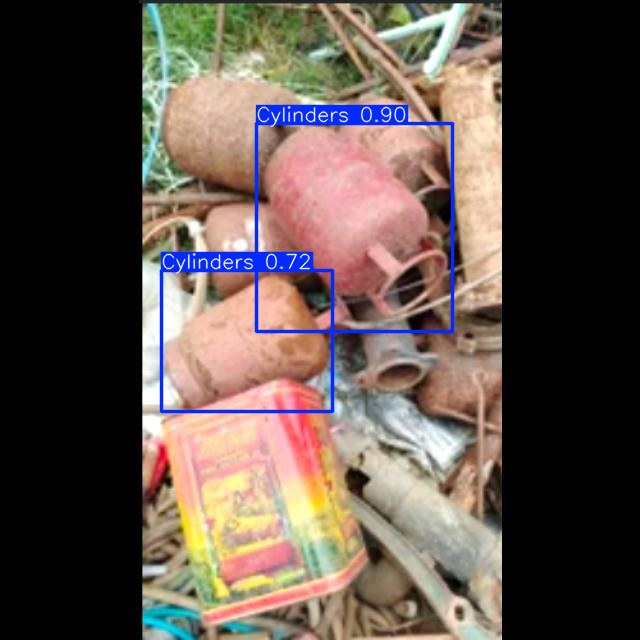

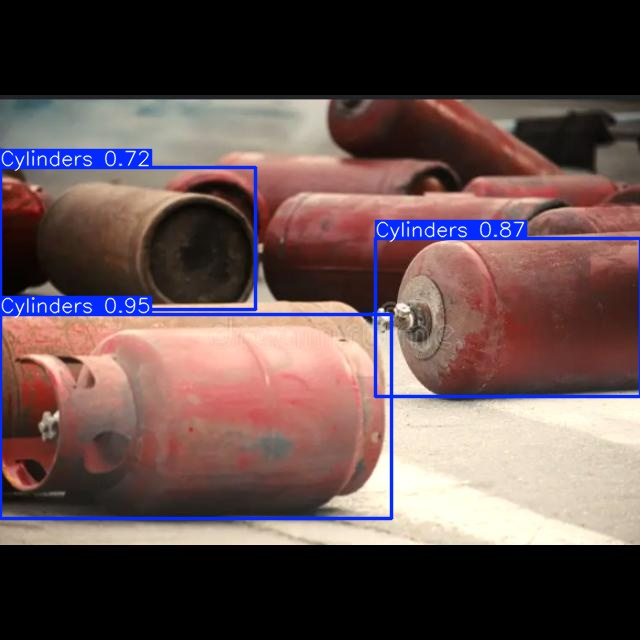

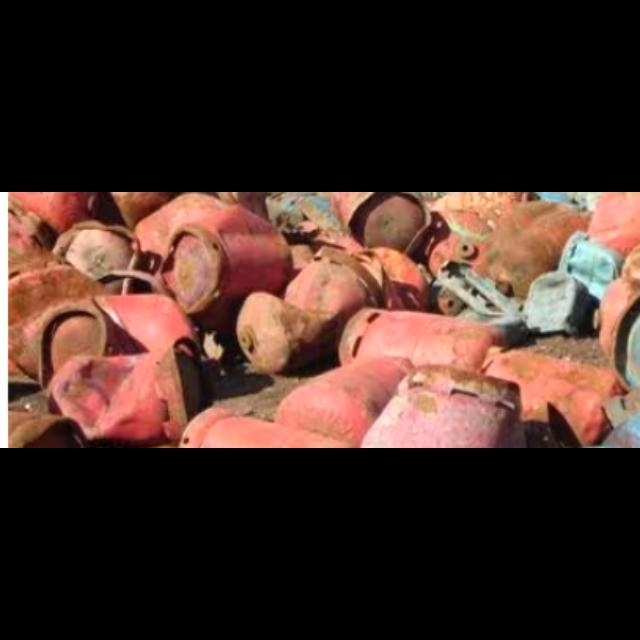

In [9]:
from IPython.display import Image, display
import os

output_folder = "/content/runs/detect/predict"

# show first 5 images
for img in os.listdir(output_folder)[:30]:
    display(Image(filename=os.path.join(output_folder, img)))